# Dynamask: learned dynamic perturbation masks

Reference: Crabbé & van der Schaar,
[*Explaining Time Series Predictions with Dynamic Masks*](https://arxiv.org/abs/2106.05303)
(ICML 2021). Reference implementation:
[JonathanCrabbe/Dynamask](https://github.com/JonathanCrabbe/Dynamask) (MIT).
`src/ts_interp/dynamask.py` is an independent implementation following the
paper's formulation, not a vendored copy.

Occlusion — the strongest baseline in the
[first notebook](occlusion_vs_integrated_gradients.ipynb) — works by blanking a
fixed-width window and measuring the drop in predicted probability. That bakes in
two assumptions: the important region is **contiguous**, and it is about
**`window` samples wide**. Neither is knowable in advance on real wearable data,
and neither is constant across subjects.

Dynamask drops both. It learns a continuous mask `M ∈ [0,1]` over the whole
signal by gradient descent. Three pieces make that work, and this notebook takes
them one at a time.

## What is in `src/`

Developer notes: [`src/ts_interp/README.md`](../../src/ts_interp/README.md).

| Symbol | Role |
| --- | --- |
| `dynamask.GaussianBlur` | the perturbation operator — mask 1 keeps the value, mask 0 blurs toward neighbours |
| `dynamask.Mask` | one mask fitted at one target area |
| `dynamask.MaskGroup` | several areas at once, plus `get_extremal_mask` |
| `dynamask.make_black_box` | adapts a repo classifier to the interface Dynamask expects |
| `attribution.top_k_overlap` | the same IoU scoring used for occlusion and IG |


In [1]:
import sys, time
sys.path.insert(0, "../../src")

import numpy as np
import torch
import matplotlib.pyplot as plt

from ts_interp import data, model, attribution, dynamask

np.random.seed(0)
torch.manual_seed(0)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. The perturbation operator

This is the piece that matters most, and the piece a naive implementation gets
wrong.

Zeroing a masked-out region — what plain occlusion does — creates a
discontinuity no real sensor would produce. The model's reaction to that
artefact is not evidence about the signal; it is evidence about how the network
handles a cliff edge.

Dynamask instead **blurs toward a Gaussian-weighted average of neighbouring
timesteps**. The mask controls the width:

```
sigma(t, c) = sigma_max * (1 + eps - M[t, c])
```

So `M = 1` gives `sigma -> 0` — a delta function that returns the original value
untouched — and `M = 0` gives the widest blur. Everything in between interpolates
smoothly, which is what makes the operator **differentiable in the mask**. That
differentiability is the whole trick: the fidelity loss can backpropagate through
the perturbation, through the model, and all the way down to individual mask
values.

Note also that the perturbed signal is a convex combination of *real values from
the same signal*, so it stays in a plausible range no matter what the mask does.

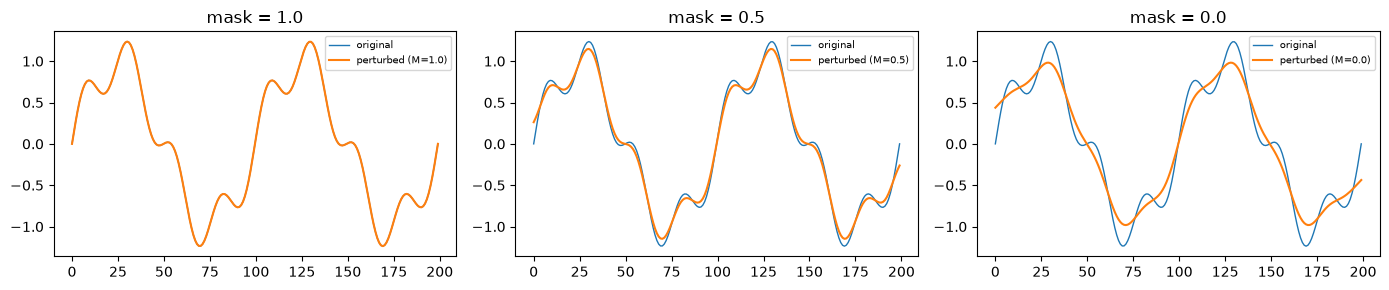

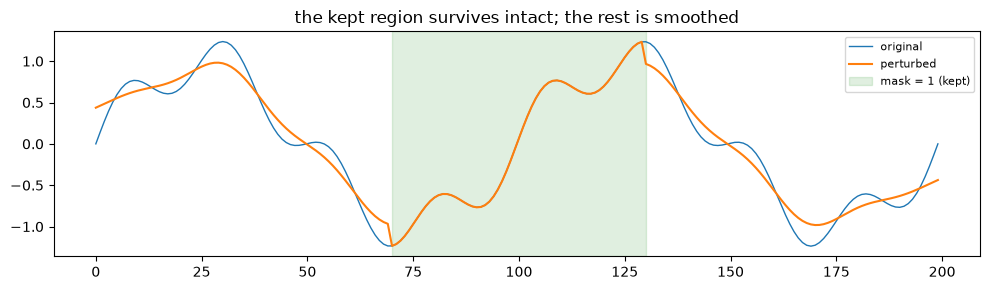

In [2]:
t = np.linspace(0, 4 * np.pi, 200)
sig = (np.sin(t) + 0.3 * np.sin(4 * t)).astype(np.float32).reshape(200, 1)
sig_t = torch.from_numpy(sig)

gb = dynamask.GaussianBlur(sigma_max=6.0)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, mval in zip(axes, [1.0, 0.5, 0.0]):
    pert = gb.apply(sig_t, torch.full((200, 1), mval)).numpy()
    ax.plot(sig[:, 0], label="original", lw=1)
    ax.plot(pert[:, 0], label=f"perturbed (M={mval})", lw=1.5)
    ax.set_title(f"mask = {mval}"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

# a partial mask: keep the middle, blur the edges
m = torch.zeros(200, 1); m[70:130] = 1.0
pert = gb.apply(sig_t, m).numpy()
plt.figure(figsize=(10, 3))
plt.plot(sig[:, 0], label="original", lw=1)
plt.plot(pert[:, 0], label="perturbed", lw=1.5)
plt.axvspan(70, 130, color="green", alpha=0.12, label="mask = 1 (kept)")
plt.legend(fontsize=8); plt.title("the kept region survives intact; the rest is smoothed")
plt.tight_layout(); plt.show()

## 2. The loss, and why the size term is not optional

The mask is fitted against two competing terms.

**Fidelity** — the perturbed input should still produce roughly the original
prediction. This forces the mask to retain whatever actually drives the model.

**Size** — the mask should be small. Without this, the trivial solution wins: a
mask of all ones preserves the prediction perfectly and explains nothing. The
paper implements it by sorting the mask values and pushing them toward a
reference vector holding `(1 - a)` zeros followed by `a` ones, where `a` is the
target **area**. That constrains *how much* is kept without dictating *which*
entries are kept — the fidelity term decides where the retained mass lands.

One implementation detail worth knowing: the size-regularisation weight is
**annealed geometrically** across training rather than held fixed. Early on the
mask explores with the area barely constrained; by the end the constraint
dominates and the mask must commit. Starting at full strength collapses the mask
before fidelity has had a chance to shape it.

test accuracy: 0.970


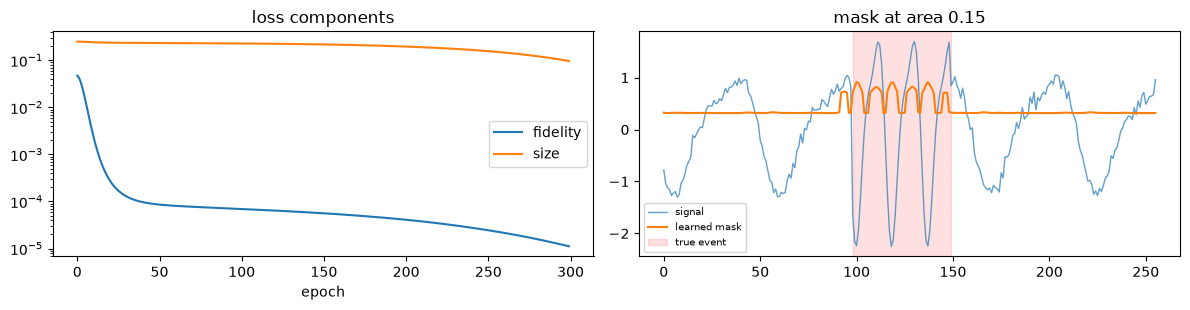

In [3]:
ds = data.make_dataset(n_samples=400, length=256, seed=0)
train_ds, test_ds = data.train_test_split(ds, test_frac=0.25, seed=0)

clf = model.TSClassifier()
model.train(clf, train_ds.x, train_ds.y, epochs=30)
print(f"test accuracy: {model.accuracy(clf, test_ds.x, test_ds.y):.3f}")

black_box = dynamask.make_black_box(clf)
idx = np.where(test_ds.y == 1)[0][0]
x, window = test_ds.x[idx], tuple(test_ds.event_windows[idx])

mask_obj = dynamask.Mask(dynamask.GaussianBlur(sigma_max=6.0))
mask_obj.fit(x, black_box, loss_function=dynamask.mse,
             keep_ratio=0.15, n_epoch=300, size_reg_factor_init=0.01)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
axes[0].plot(mask_obj.history.fidelity, label="fidelity")
axes[0].plot(mask_obj.history.size, label="size")
axes[0].set_xlabel("epoch"); axes[0].set_yscale("log"); axes[0].legend()
axes[0].set_title("loss components")

axes[1].plot(x[0], label="signal", lw=1, alpha=0.7)
axes[1].plot(mask_obj.mask[0], label="learned mask", lw=1.5)
axes[1].axvspan(*window, color="red", alpha=0.12, label="true event")
axes[1].legend(fontsize=7); axes[1].set_title("mask at area 0.15")
plt.tight_layout(); plt.show()

## 3. Areas and the extremal mask

The target area is a hyperparameter, and picking one arbitrarily makes the
explanation a function of that arbitrary choice. The paper's answer is to fit a
**group** of masks across several areas and then select the **extremal mask**:
the smallest area whose fidelity error is still below a tolerance `epsilon`.
Conceptually, the point past which granting the mask more area stops buying
meaningful fidelity.

area   fidelity error
0.10   0.000033  <- extremal
0.15   0.000011
0.20   0.000006
0.25   0.000005


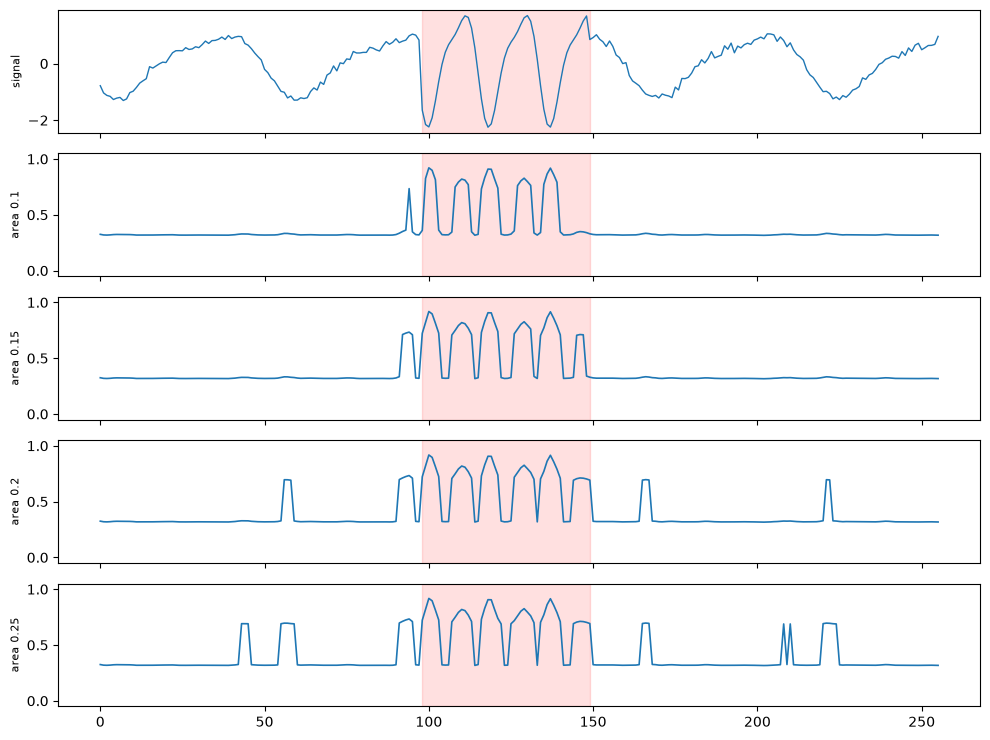

In [4]:
AREAS = [0.1, 0.15, 0.2, 0.25]
group = dynamask.MaskGroup(dynamask.GaussianBlur(sigma_max=6.0))
group.fit(x, black_box, loss_function=dynamask.mse, area_list=AREAS,
          n_epoch=300, size_reg_factor_init=0.01)

errors = group.get_errors()
extremal = group.get_extremal_mask(threshold=0.01)
print("area   fidelity error")
for a, e in zip(AREAS, errors):
    flag = "  <- extremal" if a == extremal.keep_ratio else ""
    print(f"{a:<6.2f} {e:.6f}{flag}")

fig, axes = plt.subplots(len(AREAS) + 1, 1, figsize=(10, 1.5 * (len(AREAS) + 1)), sharex=True)
axes[0].plot(x[0], lw=1); axes[0].axvspan(*window, color="red", alpha=0.12)
axes[0].set_ylabel("signal", fontsize=8)
for ax, m, a in zip(axes[1:], group.mask_list, AREAS):
    ax.plot(m.mask[0], lw=1.2)
    ax.axvspan(*window, color="red", alpha=0.12)
    ax.set_ylabel(f"area {a}", fontsize=8); ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()

### A caveat on the extremal criterion

Look at the fidelity errors above before reading the selected area as meaningful.

The criterion only discriminates when the perturbation is **strong enough to
actually move the prediction**. If every area's error already sits far below
`epsilon`, then every area "passes" and `get_extremal_mask` returns the smallest
one by default — not because it was judged best, but because nothing was
rejected. The selection has degenerated into "always pick `area_list[0]`".

That is a property of the interaction between the model's confidence, the
perturbation strength, and `epsilon` — not a bug — but it means the number
`epsilon = 0.01` cannot be transplanted between datasets without checking the
error scale first.

## 4. `sigma_max` is load-bearing

The blur width has to be matched to the timescale of whatever the model is
detecting. Here the injected burst oscillates with a period of roughly 15-29
samples, and the background pulse has a period near 53.

- **Too small**: the blur barely changes the signal, fidelity error stays at ~0
  for every area, and the mask is driven entirely by the size term — it is
  reporting the area constraint back at you, not an explanation.
- **Too large**: the blur destroys the background signal too, so no mask of
  reasonable area can preserve the prediction and fidelity never gets low.

The sweep below is a **sensitivity analysis, not a tuning procedure** — it uses
the same IoU that gets reported, so treating its argmax as "the right value"
would be fitting to the evaluation. It is here to show the size of the effect.

sigma_max=2   mean fidelity err @area0.1 = 0.00003   mean IoU = 0.412


sigma_max=4   mean fidelity err @area0.1 = 0.00043   mean IoU = 0.505


sigma_max=6   mean fidelity err @area0.1 = 0.00118   mean IoU = 0.517


sigma_max=8   mean fidelity err @area0.1 = 0.00217   mean IoU = 0.516


sigma_max=12  mean fidelity err @area0.1 = 0.00610   mean IoU = 0.309


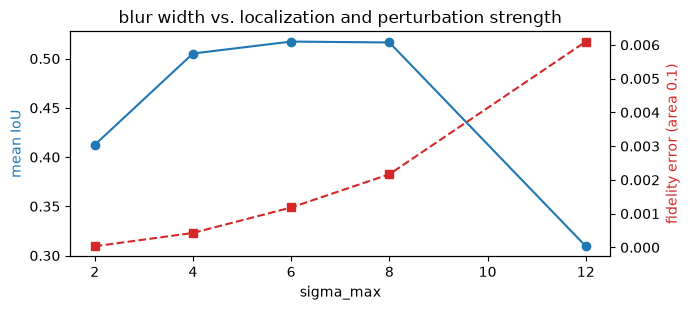

In [5]:
ev_small = np.where(test_ds.y == 1)[0][:12]
rows = []
for sm in [2, 4, 6, 8, 12]:
    ious, errs = [], []
    for i in ev_small:
        g = dynamask.MaskGroup(dynamask.GaussianBlur(sigma_max=float(sm)))
        g.fit(test_ds.x[i], black_box, area_list=AREAS, n_epoch=300, size_reg_factor_init=0.01)
        e = g.get_extremal_mask(threshold=0.01)
        ious.append(attribution.top_k_overlap(e.mask, tuple(test_ds.event_windows[i])))
        errs.append(g.get_errors()[0])
    rows.append((sm, np.mean(errs), np.mean(ious)))
    print(f"sigma_max={sm:<3} mean fidelity err @area0.1 = {np.mean(errs):.5f}   mean IoU = {np.mean(ious):.3f}")

fig, ax1 = plt.subplots(figsize=(7, 3.2))
s, e, i_ = zip(*rows)
ax1.plot(s, i_, "o-", color="tab:blue"); ax1.set_xlabel("sigma_max")
ax1.set_ylabel("mean IoU", color="tab:blue")
ax2 = ax1.twinx(); ax2.plot(s, e, "s--", color="tab:red")
ax2.set_ylabel("fidelity error (area 0.1)", color="tab:red")
plt.title("blur width vs. localization and perturbation strength")
plt.tight_layout(); plt.show()

## Takeaways

**The perturbation operator is the heart of the method.** Blurring toward a
neighbourhood average keeps the perturbed signal on the data manifold in a way
that zeroing does not — every perturbed value is a convex combination of real
values from the same trace. That is what makes the fidelity signal meaningful:
the model is reacting to *less information*, not to an artificial cliff edge.

**`sigma_max` has to match the signal's timescale, and the fidelity error tells
you when it doesn't.** The sweep above shows a plateau between roughly 4 and 8
with sharp falloff either side:

| `sigma_max` | fidelity err @ area 0.1 | mean IoU |
| --- | --- | --- |
| 2 (paper default) | 0.00003 | 0.412 |
| 4 | 0.00043 | 0.505 |
| 6 | 0.00118 | 0.517 |
| 8 | 0.00217 | 0.516 |
| 12 | 0.00610 | 0.309 |

At `sigma_max=2` the fidelity error is ~3e-5 — the blur is barely perturbing a
burst whose period is 15-29 samples, so the fidelity gradient carries almost no
information and the mask is shaped by the size term alone. At 12 the blur
destroys the background pulse too, and no mask of reasonable area can preserve
the prediction. **A near-zero fidelity error across every area is the diagnostic
that `sigma_max` is too small** — it is visible without any ground truth, which
matters because on real data you will not have any.

Note the paper's default sits in the too-weak regime *for this dataset*. That is
not a criticism of the default; it is the point that the parameter is coupled to
the data's timescale and cannot be inherited.

**The extremal-mask criterion degenerates here.** Every area's fidelity error
(3e-5 down to 5e-6) sits orders of magnitude below `epsilon = 0.01`, so every
area passes and `get_extremal_mask` returns the smallest one by default. It is
not choosing; it is defaulting. Check the scale of `get_errors()` before reading
the selected area as a finding — `epsilon = 0.01` does not transplant between
datasets, and a criterion that always fires is indistinguishable from no
criterion at all.

**What Dynamask actually buys.** It does not beat occlusion on this task (see
the [comparison notebook](occlusion_vs_integrated_gradients.ipynb)). What it
removes is a guess: occlusion's window width is a hyperparameter you must know
in advance, and on real wearable data you do not — event duration varies by
subject and condition. Dynamask learns the extent of the important region
instead. It trades that guess for `sigma_max`, and the table above shows that is
not a free trade.

**Is the fidelity term earning its place?** Yes — `scripts/validate_dynamask.py`
compares a fitted mask against a random mask of identical area and finds 0.552
vs 0.148 IoU, with fidelity error 0.006 vs 0.248. The area constraint alone does
not produce these masks. Worth re-running that check after any change to the
operator or the loss.
